In [81]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [82]:
df = pd.read_csv("/content/health.csv.csv")
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

display(df.head())
print("Shape:", df.shape)

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,26.0,Female,North,25.63,108.850,150.05,127.12,0
1,P0002,42.0,Male,East,24.84,125.110,165.48,87.12,0
2,P0003,NaN,Male,West,48.14,199.296,333.40,186.48,0
3,P0004,47.0,Female,East,28.40,112.740,181.69,73.63,0
4,P0005,44.0,Male,North,20.55,118.760,164.98,90.62,0


Shape: (200, 9)


In [83]:
display(df.info())
display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      200 non-null    object 
 1   age             180 non-null    float64
 2   gender          180 non-null    object 
 3   region          180 non-null    object 
 4   bmi             180 non-null    float64
 5   blood_pressure  200 non-null    float64
 6   cholesterol     180 non-null    float64
 7   glucose         180 non-null    float64
 8   disease_risk    200 non-null    int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 14.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,200,200,P0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,180.0,NaN,NaN,NaN,50.333333,18.120947,20.0,35.0,50.0,67.0,79.0
gender,180,2,Male,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,180,4,South,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,180.0,NaN,NaN,NaN,29.962056,8.821297,16.14,23.94,27.87,34.8825,75.04
blood_pressure,200.0,NaN,NaN,NaN,136.15147,29.01328,95.6,115.915,132.905,148.25,283.662
cholesterol,180.0,NaN,NaN,NaN,229.707278,68.568846,134.95,183.3725,219.09,260.12,620.82
glucose,180.0,NaN,NaN,NaN,132.220722,45.302392,64.06,96.3075,128.45,156.7175,335.46
disease_risk,200.0,NaN,NaN,NaN,0.5,0.501255,0.0,0.0,0.5,1.0,1.0


In [84]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

display(missing)

,missing_count,missing_percent
age,20,10.0
cholesterol,20,10.0
gender,20,10.0
region,20,10.0
bmi,20,10.0
glucose,20,10.0
patient_id,0,0.0
blood_pressure,0,0.0
disease_risk,0,0.0


In [85]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)

Duplicate rows before: 0
Shape after duplicate removal: (200, 9)


In [86]:
target = "disease_risk"
id_col = "patient_id" if "patient_id" in df.columns else None

num_cols = ["age", "bmi", "blood_pressure", "cholesterol", "glucose"]
cat_cols = ["gender", "region"]

In [87]:
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [88]:
df["bp_glucose_ratio"] = df["blood_pressure"] / (df["glucose"] + 1e-5)
df["cholesterol_bmi_ratio"] = df["cholesterol"] / (df["bmi"] + 1e-5)
df["age_bmi_interaction"] = df["age"] * df["bmi"]
df["risk_score_raw"] = (
    0.25 * df["age"] +
    0.25 * df["bmi"] +
    0.25 * df["blood_pressure"] +
    0.125 * df["cholesterol"] +
    0.125 * df["glucose"]
)

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Young", "Adult", "Middle_Aged", "Senior"]
)

df["bmi_group"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

In [89]:
for c in ["age", "bmi", "cholesterol", "glucose"]:
    df[f"{c}_missing"] = df[c].isna().astype(int)

In [90]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df["age_group"] = df["age_group"].astype(str)
df["bmi_group"] = df["bmi_group"].astype(str)

In [91]:
clip_cols = num_cols + ["bp_glucose_ratio", "cholesterol_bmi_ratio", "age_bmi_interaction", "risk_score_raw"]

for c in clip_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[c] = df[c].clip(lower, upper)

In [92]:
corr = df.select_dtypes(include=np.number).corr()
corr = corr.rename(columns={
    "blood_pressure": "BP",
    "cholesterol": "Chol",
    "disease_risk": "Risk"
}, index={
    "blood_pressure": "BP",
    "cholesterol": "Chol",
    "disease_risk": "Risk"
})

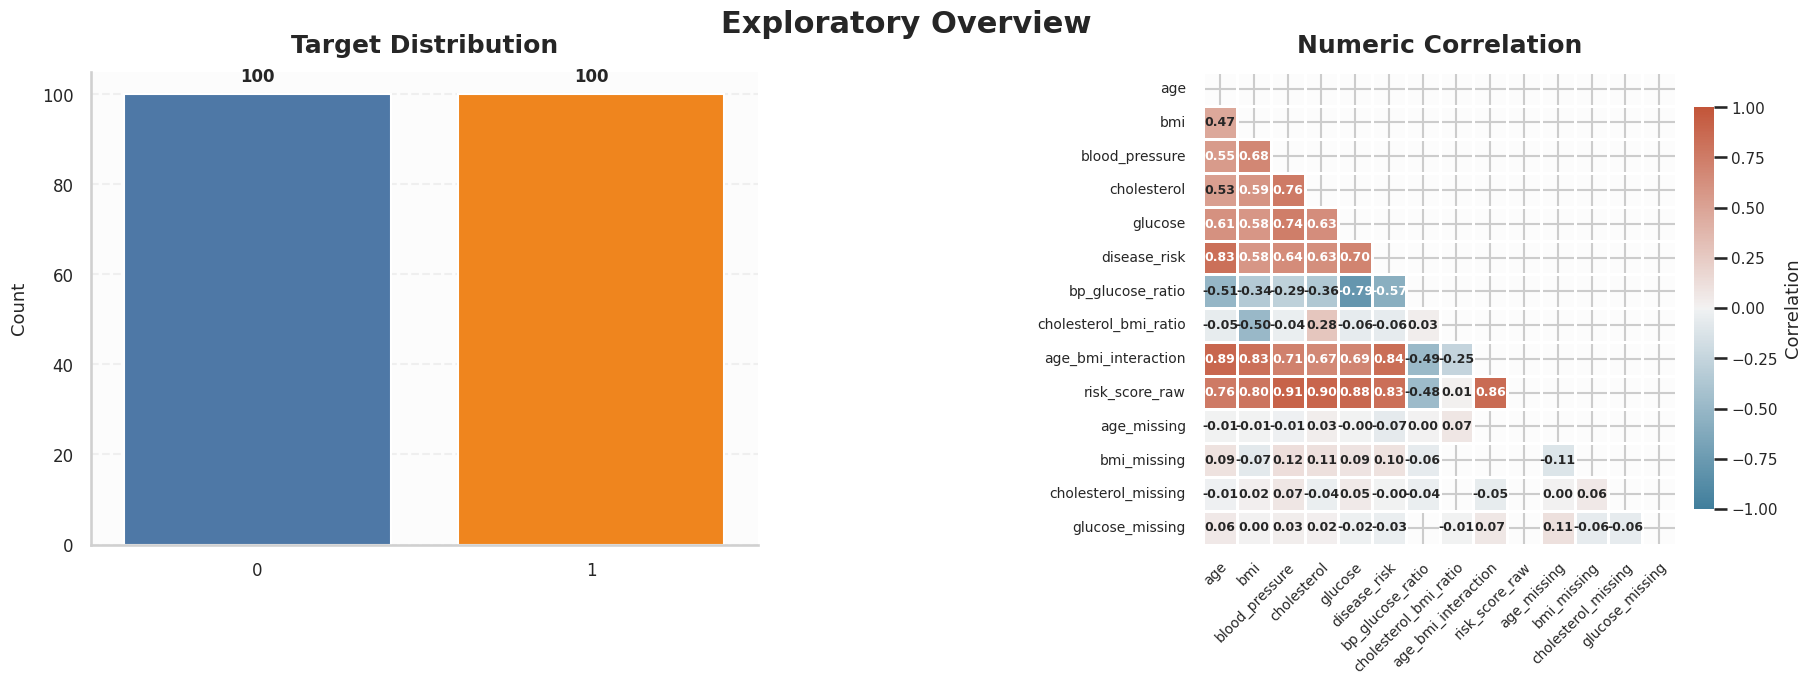

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFC",
    "axes.edgecolor": "#D0D0D0",
    "axes.labelsize": 13,
    "axes.titlesize": 18,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.family": "DejaVu Sans"
})

fig, ax = plt.subplots(
    1, 2,
    figsize=(18, 6.5),
    gridspec_kw={"width_ratios": [1, 1.35]},
    constrained_layout=True
)

# Left: Target distribution
target_palette = ["#4C78A8", "#F58518"]
sns.countplot(
    data=df,
    x=target,
    ax=ax[0],
    palette=target_palette,
    edgecolor="white",
    linewidth=1.5,
    saturation=0.95
)

ax[0].set_title("Target Distribution", fontsize=18, fontweight="bold", pad=14)
ax[0].set_xlabel("")
ax[0].set_ylabel("Count", fontsize=13, labelpad=10)
ax[0].grid(axis="y", linestyle="--", alpha=0.25)
ax[0].set_facecolor("#FCFCFC")
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["left"].set_color("#D0D0D0")
ax[0].spines["bottom"].set_color("#D0D0D0")
ax[0].tick_params(axis="both", labelsize=12)

for p in ax[0].patches:
    h = p.get_height()
    ax[0].annotate(
        f"{int(h)}",
        (p.get_x() + p.get_width() / 2., h),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        xytext=(0, 6),
        textcoords="offset points"
    )

# Right: Correlation heatmap
corr = df.select_dtypes(include=np.number).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    ax=ax[1],
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9, "weight": "bold"},
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"shrink": 0.85, "label": "Correlation", "pad": 0.02}
)

ax[1].set_title("Numeric Correlation", fontsize=18, fontweight="bold", pad=14)
ax[1].set_xlabel("")
ax[1].set_ylabel("")

ax[1].tick_params(axis="x", labelrotation=45, labelsize=10, pad=2)
ax[1].tick_params(axis="y", labelrotation=0, labelsize=10)

for label in ax[1].get_xticklabels():
    label.set_horizontalalignment("right")
    label.set_rotation_mode("anchor")

for spine in ax[1].spines.values():
    spine.set_visible(False)

fig.suptitle("Exploratory Overview", fontsize=22, fontweight="bold", y=1.03)
plt.show()

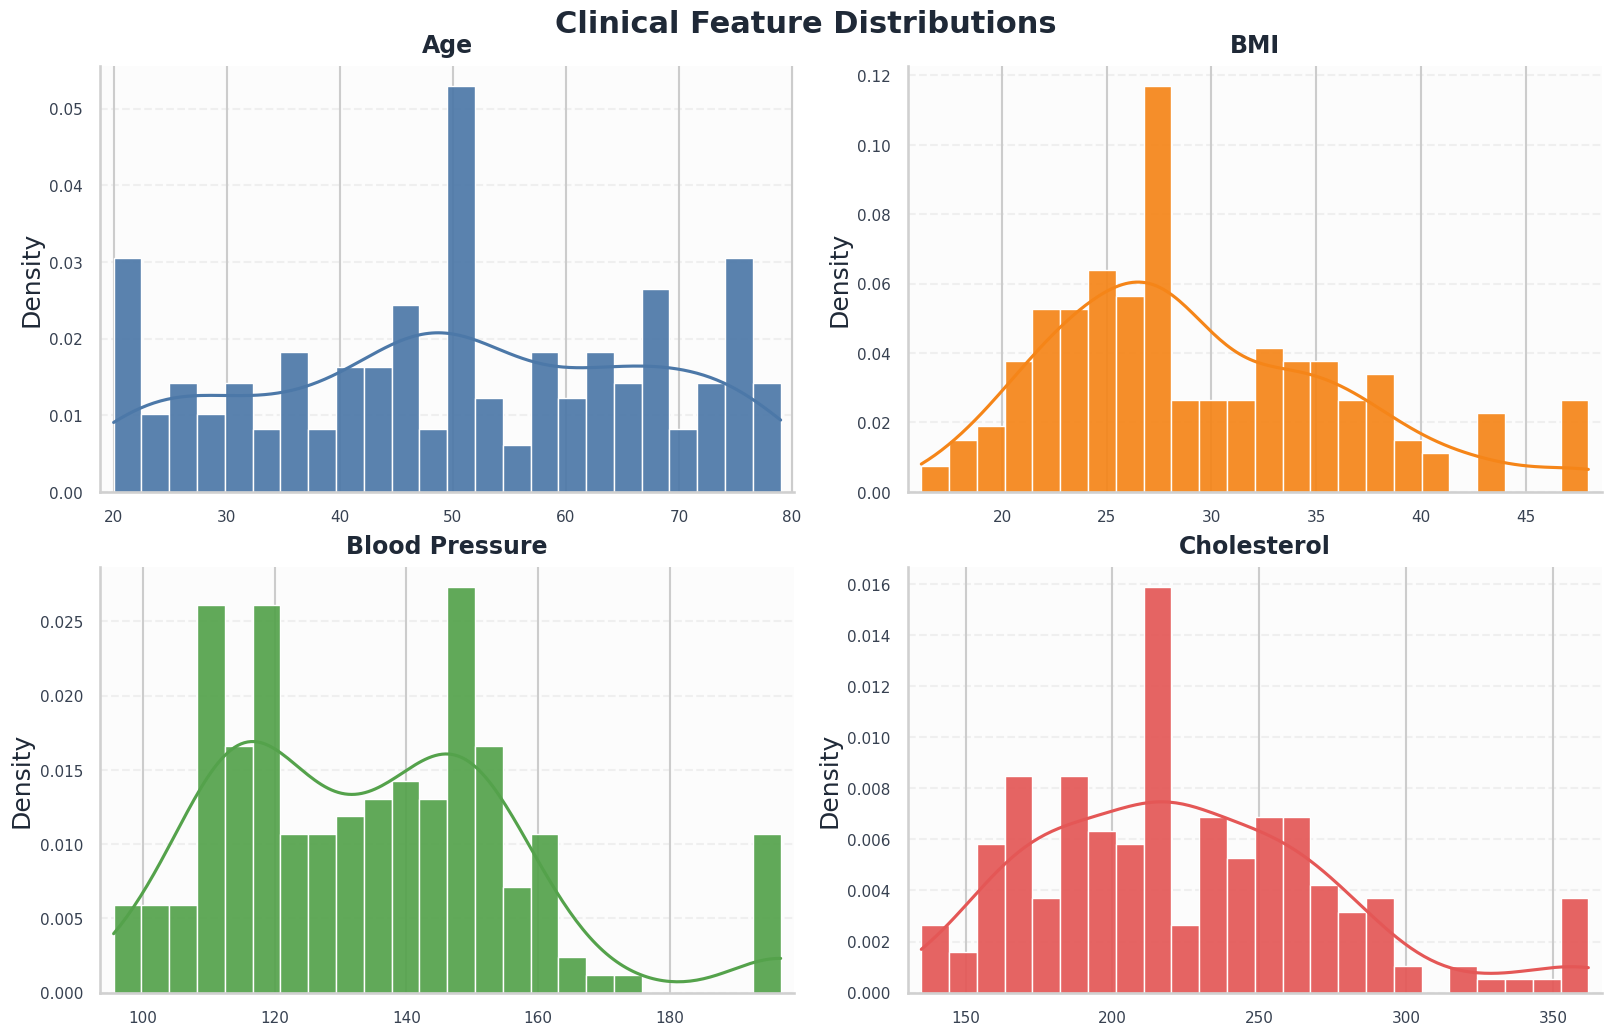

In [94]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFC",
    "axes.edgecolor": "#D0D0D0",
    "axes.labelcolor": "#1f2937",
    "text.color": "#1f2937",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "DejaVu Sans"
})

features = ["age", "bmi", "blood_pressure", "cholesterol"]
titles = ["Age", "BMI", "Blood Pressure", "Cholesterol"]
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
fig.suptitle(
    "Clinical Feature Distributions",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

for ax, col, title, color in zip(axes.flat, features, titles, colors):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=24,
        stat="density",
        color=color,
        edgecolor="white",
        linewidth=1.0,
        alpha=0.92,
        ax=ax
    )

    ax.set_title(title, fontsize=17, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D0D0D0")
    ax.spines["bottom"].set_color("#D0D0D0")
    ax.tick_params(labelsize=11)
    ax.margins(x=0.02)

    fig.suptitle("Clinical Feature Distributions", fontsize=22, fontweight="bold", y=1.02)

plt.show()

In [95]:
drop_cols = [target] + ([id_col] if id_col else [])
X = df.drop(columns=drop_cols)
y = df[target]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [97]:
all_num_cols = [
    "age", "bmi", "blood_pressure", "cholesterol", "glucose",
    "bp_glucose_ratio", "cholesterol_bmi_ratio", "age_bmi_interaction",
    "risk_score_raw", "age_missing", "bmi_missing", "cholesterol_missing", "glucose_missing"
]

all_cat_cols = ["gender", "region", "age_group", "bmi_group"]

In [98]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, all_num_cols),
    ("cat", categorical_transformer, all_cat_cols)
])

In [99]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "Extra Trees": ExtraTreesClassifier(random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

In [100]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bench_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    bench_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

bench_df = pd.DataFrame(bench_results).sort_values("CV Mean Accuracy", ascending=False)
display(bench_df)

,Model,CV Mean Accuracy,CV Std
2,Random Forest,0.99375,0.012500
6,XGBoost,0.98125,0.025000
3,Extra Trees,0.97500,0.030619
0,Logistic Regression,0.96250,0.030619
1,Decision Tree,0.95625,0.015309
4,Gradient Boosting,0.95625,0.025000
5,KNN,0.95625,0.031869


In [101]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__solver": ["liblinear", "lbfgs"]
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, None],
        "model__min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5]
    },
    "Extra Trees": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 5, 10]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"]
    }
}

if XGBClassifier is not None:
    param_grids["XGBoost"] = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 0.9],
        "model__colsample_bytree": [0.8, 0.9]
    }

In [102]:
best_models = []
best_score = -1
best_name = None
best_pipe = None

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_models.append({
        "Model": name,
        "Best CV Accuracy": grid.best_score_,
        "Best Params": grid.best_params_
    })

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_name = name
        best_pipe = grid.best_estimator_

tuning_df = pd.DataFrame(best_models).sort_values("Best CV Accuracy", ascending=False)
display(tuning_df)
print("Best tuned model:", best_name)

,Model,Best CV Accuracy,Best Params
2,Random Forest,0.99375,"{'model__max_depth': None, 'model__min_samples..."
6,XGBoost,0.99375,"{'model__colsample_bytree': 0.9, 'model__learn..."
3,Extra Trees,0.98750,"{'model__max_depth': None, 'model__n_estimator..."
4,Gradient Boosting,0.98125,"{'model__learning_rate': 0.05, 'model__max_dep..."
5,KNN,0.97500,"{'model__n_neighbors': 3, 'model__weights': 'u..."
0,Logistic Regression,0.96875,"{'model__C': 0.1, 'model__solver': 'liblinear'}"
1,Decision Tree,0.95625,"{'model__max_depth': 3, 'model__min_samples_sp..."


Best tuned model: Random Forest


In [103]:
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_prob)
}

final_metrics_df = pd.DataFrame([final_metrics], index=[best_name])
display(final_metrics_df)
print(classification_report(y_test, y_pred))

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,0.975,0.952381,1.0,0.97561,0.9925


              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.95      1.00      0.98        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



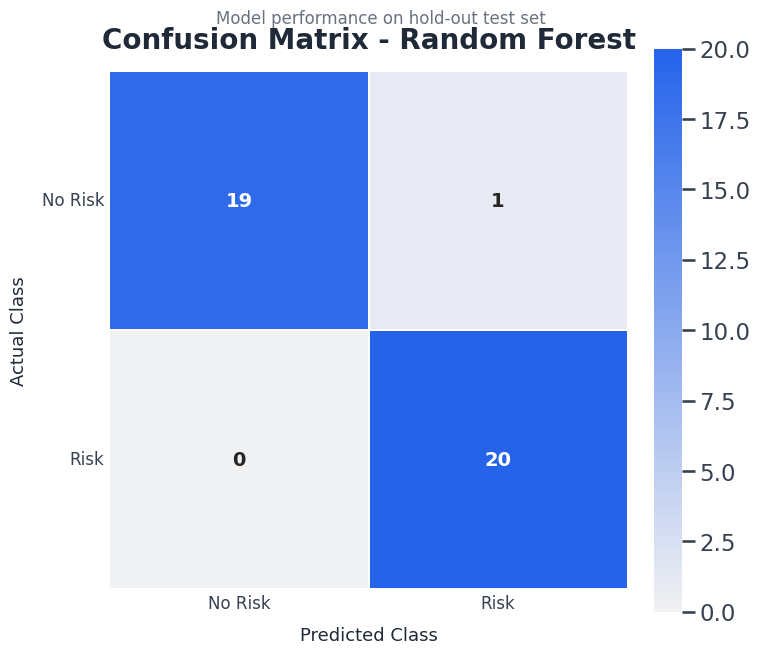

In [104]:
sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFC",
    "axes.edgecolor": "#D0D0D0",
    "axes.labelcolor": "#1f2937",
    "text.color": "#1f2937",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "DejaVu Sans"
})

cm = confusion_matrix(y_test, y_pred)
labels = ["No Risk", "Risk"]

fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.light_palette("#2563EB", as_cmap=True),
    cbar=True,
    square=True,
    linewidths=1.2,
    linecolor="white",
    annot_kws={"size": 14, "weight": "bold"},
    ax=ax
)

ax.set_title(
    f"Confusion Matrix - {best_name}",
    fontsize=20,
    fontweight="bold",
    pad=16
)
ax.set_xlabel("Predicted Class", fontsize=13, labelpad=10)
ax.set_ylabel("Actual Class", fontsize=13, labelpad=10)
ax.set_xticklabels(labels, rotation=0, fontsize=12)
ax.set_yticklabels(labels, rotation=0, fontsize=12)

ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.5, 0.98,
    "Model performance on hold-out test set",
    ha="center",
    fontsize=12,
    color="#6B7280"
)

plt.show()

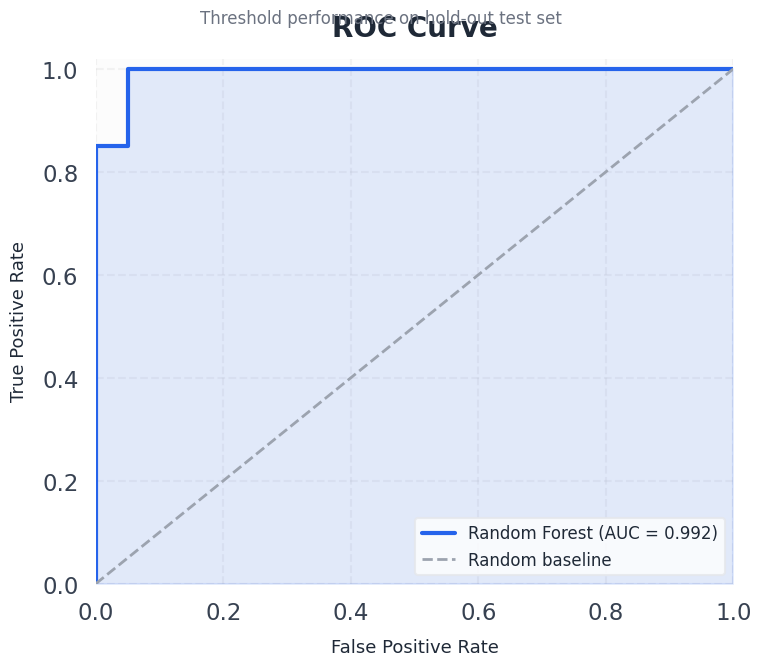

In [105]:
sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFC",
    "axes.edgecolor": "#D0D0D0",
    "axes.labelcolor": "#1f2937",
    "text.color": "#1f2937",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "DejaVu Sans"
})

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)

ax.plot(
    fpr, tpr,
    color="#2563EB",
    linewidth=3,
    label=f"{best_name} (AUC = {auc_score:.3f})"
)
ax.fill_between(fpr, tpr, color="#2563EB", alpha=0.12)
ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="#9CA3AF",
    linewidth=2,
    label="Random baseline"
)

ax.set_title("ROC Curve", fontsize=20, fontweight="bold", pad=16)
ax.set_xlabel("False Positive Rate", fontsize=13, labelpad=10)
ax.set_ylabel("True Positive Rate", fontsize=13, labelpad=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(True, linestyle="--", alpha=0.22)
ax.legend(frameon=True, facecolor="white", edgecolor="#E5E7EB", fontsize=12, loc="lower right")

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.5, 0.98,
    "Threshold performance on hold-out test set",
    ha="center",
    fontsize=12,
    color="#6B7280"
)

plt.show()

,feature,importance
0,age,0.214423
2,blood_pressure,0.142003
7,age_bmi_interaction,0.128598
4,glucose,0.119261
3,cholesterol,0.073359
1,bmi,0.070935
8,risk_score_raw,0.066959
21,age_group_Senior,0.053085
5,bp_glucose_ratio,0.027790
19,age_group_Adult,0.023738


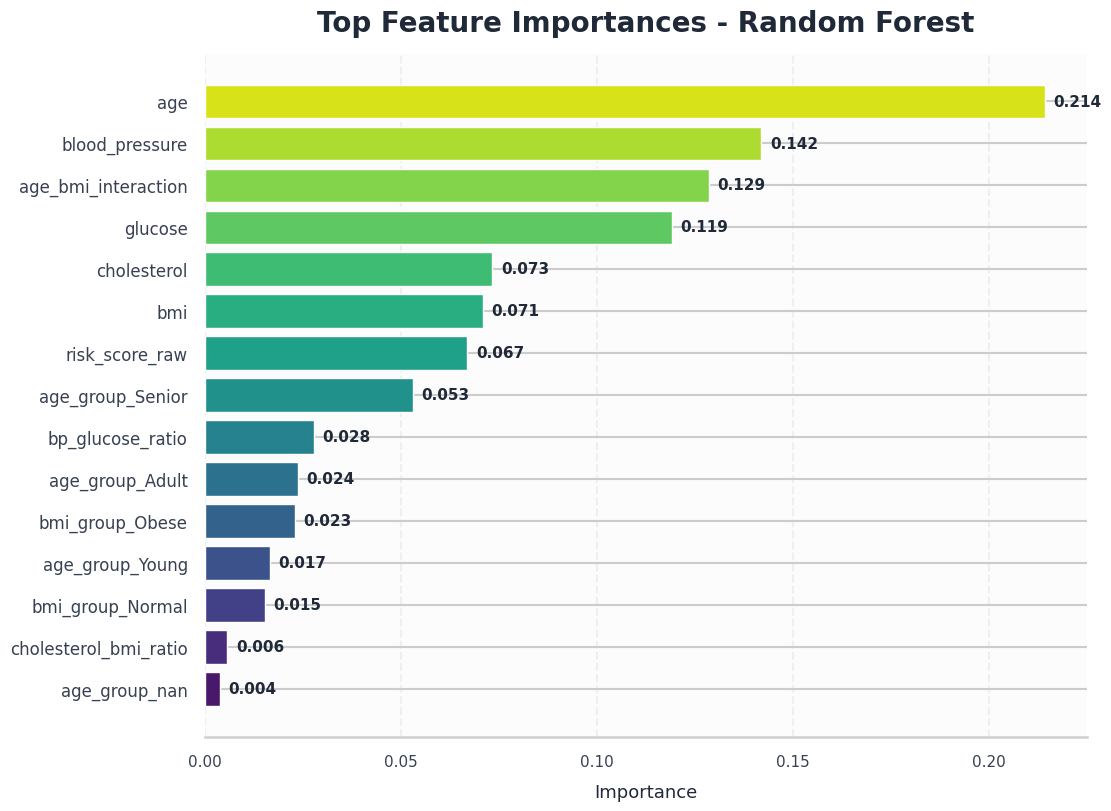

In [106]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFC",
    "axes.edgecolor": "#D0D0D0",
    "axes.labelcolor": "#1f2937",
    "text.color": "#1f2937",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "DejaVu Sans"
})

model = best_pipe.named_steps["model"]

try:
    ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["encoder"]
    cat_features = list(ohe.get_feature_names_out(all_cat_cols))
    feature_names = all_num_cols + cat_features

    if hasattr(model, "feature_importances_"):
        importances = pd.DataFrame({
            "feature": feature_names[:len(model.feature_importances_)],
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)

        display(importances.head(15))

        top = importances.head(15).sort_values("importance", ascending=True)

        fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
        colors = sns.color_palette("viridis", n_colors=len(top))

        ax.barh(
            top["feature"],
            top["importance"],
            color=colors,
            edgecolor="white",
            linewidth=1.0
        )

        ax.set_title(
            f"Top Feature Importances - {best_name}",
            fontsize=20,
            fontweight="bold",
            pad=16
        )
        ax.set_xlabel("Importance", fontsize=13, labelpad=10)
        ax.set_ylabel("")
        ax.grid(axis="x", linestyle="--", alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_color("#D0D0D0")
        ax.tick_params(axis="y", labelsize=12)
        ax.tick_params(axis="x", labelsize=11)

        for i, v in enumerate(top["importance"]):
            ax.text(
                v + max(top["importance"]) * 0.01,
                i,
                f"{v:.3f}",
                va="center",
                fontsize=11,
                fontweight="bold"
            )
        plt.show()
except Exception as e:
    print("Feature importance not available:", e)

In [107]:
Path("output").mkdir(exist_ok=True)

bench_df.to_csv("output/cv_benchmark.csv", index=False)
tuning_df.to_csv("output/tuning_results.csv", index=False)
final_metrics_df.to_csv("output/final_metrics.csv")
df.to_csv("output/cleaned_healthcare_data.csv", index=False)

print("All outputs saved in output/")

All outputs saved in output/


In [108]:
print("Project completed successfully.")
print("Best tuned model:", best_name)
print("Best CV accuracy:", round(best_score, 4))
print("Final test accuracy:", round(final_metrics["Accuracy"], 4))

Project completed successfully.
Best tuned model: Random Forest
Best CV accuracy: 0.9938
Final test accuracy: 0.975
